# Baseline, Balanceo y PCA

## Configuración

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc)
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

MODEL_COLORS = {
    'KNN':               'blue',
    'Reg. Logística':    'orange',
    'Árbol de Decisión': 'green',
    'Random Forest':     'red',
}
MODELOS = list(MODEL_COLORS.keys())

df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

os.makedirs('outputs_sprint1', exist_ok=True)
print(f'Features: {len(FEATURES)} (sin Au, sin coordenadas)')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')

Features: 46 (sin Au, sin coordenadas)
Train: (1705, 46) dist={0: 1497, 1: 208}
Test : (427, 46) dist={0: 375, 1: 52}


## Funciones

In [3]:
def crear_modelos():
    return {
        'KNN':               Pipeline([('sc', StandardScaler()),
                                       ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística':    Pipeline([('sc', StandardScaler()),
                                       ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'Árbol de Decisión': Pipeline([('sc', StandardScaler()),
                                       ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest':     Pipeline([('sc', StandardScaler()),
                                       ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED))]),
    }

BALANCEADORES = {
    'Sin balanceo':      None,
    'RandomOverSampler': RandomOverSampler(random_state=SEED),
    'SMOTE':             SMOTE(random_state=SEED, k_neighbors=5),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=SEED, k_neighbors=5),
    'ADASYN':            ADASYN(random_state=SEED),
    'SMOTETomek':        SMOTETomek(random_state=SEED),
}

def aplicar_balanceo(nombre):
    bal = BALANCEADORES[nombre]
    if bal is None:
        return X_train.copy(), y_train.copy()
    return bal.fit_resample(X_train, y_train)

def scores_pos(modelo, Xte):
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

def metricas(yte, y_pred, y_sco):
    return {
        'F1':        f1_score(yte, y_pred),
        'Accuracy':  accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0),
        'Recall':    recall_score(yte, y_pred),
        'AUC-ROC':   roc_auc_score(yte, y_sco),
    }

def evaluar_pipeline(modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte); y_sco = scores_pos(modelo, Xte)
    m = metricas(yte, y_pred, y_sco); m['_pred'] = y_pred; m['_score'] = y_sco
    return m
print('Funciones listas')

Funciones listas


## Modelos Baseline

In [7]:
res_f0 = {n: evaluar_pipeline(m, X_train, y_train, X_test, y_test)
          for n, m in crear_modelos().items()}

tabla_f0 = pd.DataFrame({m: {k: res_f0[m][k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
                         for m in MODELOS}).T[['F1','Accuracy','Precision','Recall','AUC-ROC']].round(4)

tabla_f0.to_csv('outputs_sprint1/baseline_metricas.csv')

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Métricas en HOLD-OUT')
tabla_f0.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

Métricas en HOLD-OUT


,F1,Accuracy,Precision,Recall,AUC-ROC
KNN,0.3243,0.8829,0.5455,0.2308,0.8390
Reg. Logística,0.6118,0.9227,0.7879,0.5000,0.9369
Árbol de Decisión,0.6393,0.8970,0.5571,0.7500,0.8337
Random Forest,0.6437,0.9274,0.8000,0.5385,0.9547


## Gráfico comparativo

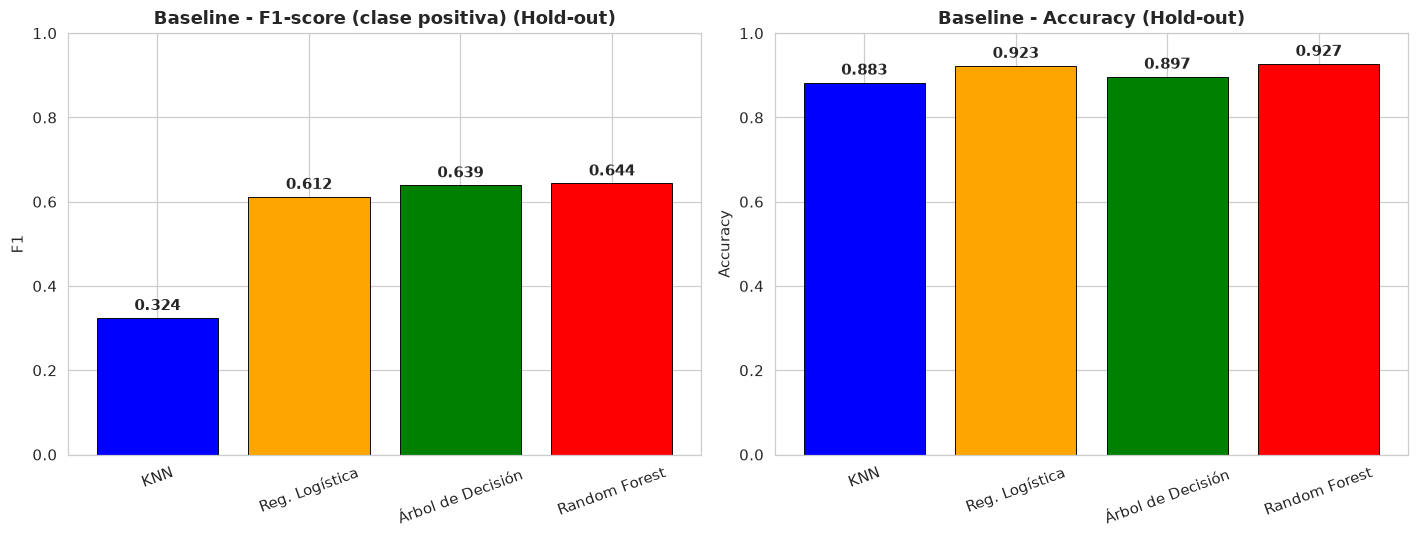

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = [MODEL_COLORS[m] for m in tabla_f0.index]
for ax, col, tit in zip(axes, ['F1','Accuracy'], ['F1-score (clase positiva)','Accuracy']):
    b = ax.bar(tabla_f0.index, tabla_f0[col], color=colores, edgecolor='black', linewidth=.6)
    ax.set_title(f'Baseline - {tit} (Hold-out)', fontweight='bold')
    ax.set_ylabel(col); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=20)
    for r in b: ax.text(r.get_x()+r.get_width()/2, r.get_height()+.01, f'{r.get_height():.3f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint1/baseline_barras.png', bbox_inches='tight'); plt.show()

## Matriz de confusión

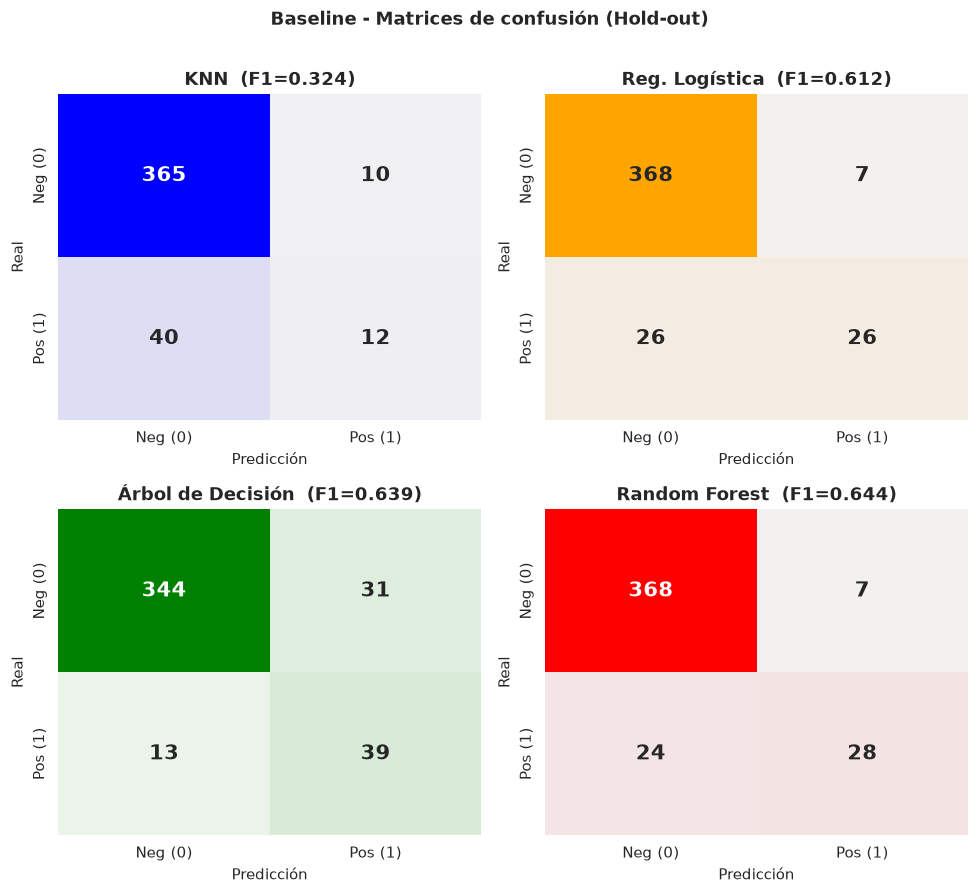

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, nombre in zip(axes.ravel(), MODELOS):
    cm = confusion_matrix(y_test, res_f0[nombre]['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                cmap=sns.light_palette(MODEL_COLORS[nombre], as_cmap=True),
                xticklabels=['Neg (0)','Pos (1)'], yticklabels=['Neg (0)','Pos (1)'],
                annot_kws={'size':14,'fontweight':'bold'})
    ax.set_title(f'{nombre}  (F1={res_f0[nombre]["F1"]:.3f})', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.suptitle('Baseline - Matrices de confusión (Hold-out)', fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('outputs_sprint1/baseline_matrices_confusion.png', bbox_inches='tight'); plt.show()

## Curva Precision-Recall y Curva ROC

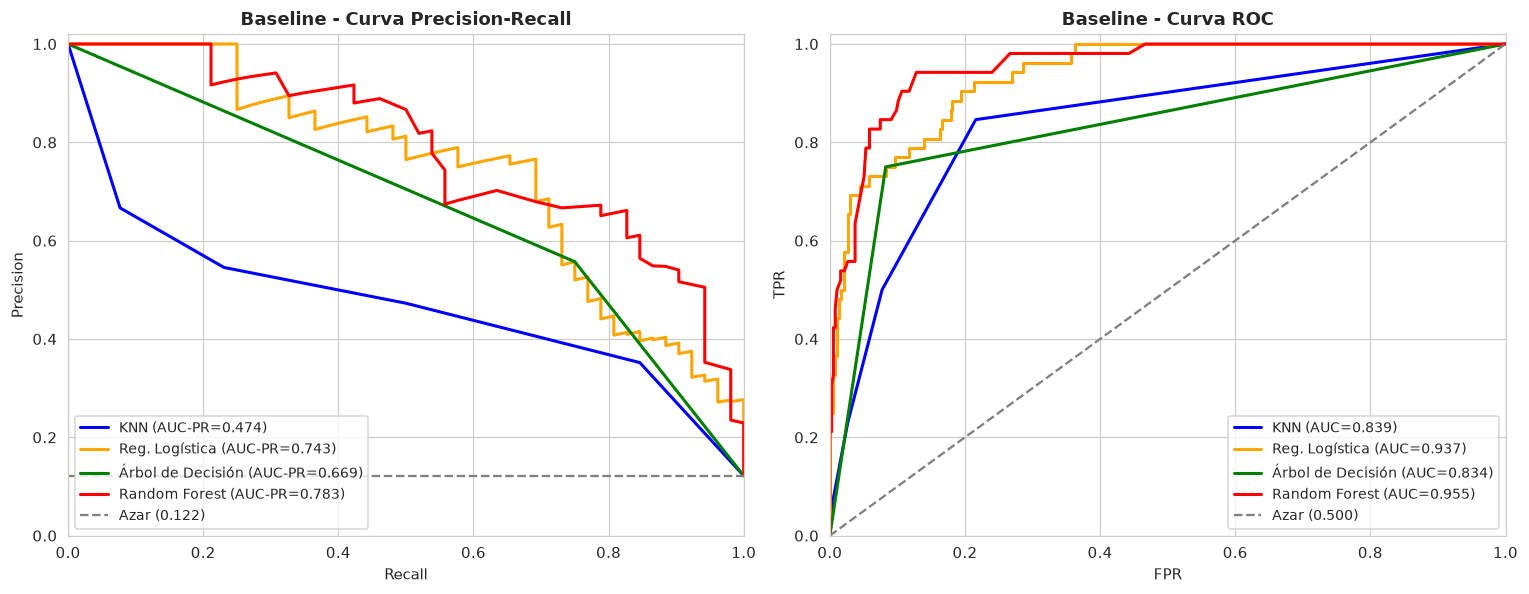

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for nombre in MODELOS:
    p, r, _ = precision_recall_curve(y_test, res_f0[nombre]['_score'])
    axes[0].plot(r, p, color=MODEL_COLORS[nombre], lw=2, label=f'{nombre} (AUC-PR={auc(r,p):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)
axes[0].set_title('Baseline - Curva Precision-Recall', fontweight='bold'); axes[0].legend(fontsize=9)
for nombre in MODELOS:
    fpr, tpr, _ = roc_curve(y_test, res_f0[nombre]['_score'])
    axes[1].plot(fpr, tpr, color=MODEL_COLORS[nombre], lw=2, label=f'{nombre} (AUC={res_f0[nombre]["AUC-ROC"]:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)
axes[1].set_title('Baseline - Curva ROC', fontweight='bold'); axes[1].legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint1/baseline_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Balanceo

In [12]:
f1_bal = pd.DataFrame(index=list(BALANCEADORES), columns=MODELOS, dtype=float)
for nb_bal in BALANCEADORES:
    Xtr_b, ytr_b = aplicar_balanceo(nb_bal)
    for nb_mod, modelo in crear_modelos().items():
        f1_bal.loc[nb_bal, nb_mod] = evaluar_pipeline(modelo, Xtr_b, ytr_b, X_test, y_test)['F1']

f1_bal = f1_bal.astype(float).round(4)
f1_bal.to_csv('outputs_sprint1/balanceo_f1.csv')

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Balanceo — F1-score (hold-out) por método de balanceo y modelo')
f1_bal.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

Balanceo — F1-score (hold-out) por método de balanceo y modelo


,KNN,Reg. Logística,Árbol de Decisión,Random Forest
Sin balanceo,0.3243,0.6118,0.6393,0.6437
RandomOverSampler,0.4895,0.5455,0.6724,0.6667
SMOTE,0.5093,0.5860,0.5481,0.7130
BorderlineSMOTE,0.5161,0.5526,0.6269,0.7069
ADASYN,0.5150,0.5696,0.5625,0.7027
SMOTETomek,0.5093,0.5860,0.5693,0.7069


## Comparación por método de balanceo

In [14]:
mejor_bal_por_modelo = {mod: f1_bal[mod].idxmax() for mod in MODELOS}
resumen_bal = pd.DataFrame({
    'Mejor método':  [mejor_bal_por_modelo[m] for m in MODELOS],
    'F1 (mejor)':    [round(f1_bal[m].max(),4) for m in MODELOS],
    'F1 (baseline)': [round(f1_bal.loc['Sin balanceo', m],4) for m in MODELOS],
}, index=MODELOS)
resumen_bal['Δ F1'] = (resumen_bal['F1 (mejor)'] - resumen_bal['F1 (baseline)']).round(4)
print('Mejor método de balanceo por modelo:')
resumen_bal

Mejor método de balanceo por modelo:


,Mejor método,F1 (mejor),F1 (baseline),Δ F1
KNN,BorderlineSMOTE,0.5161,0.3243,0.1918
Reg. Logística,Sin balanceo,0.6118,0.6118,0.0000
Árbol de Decisión,RandomOverSampler,0.6724,0.6393,0.0331
Random Forest,SMOTE,0.7130,0.6437,0.0693


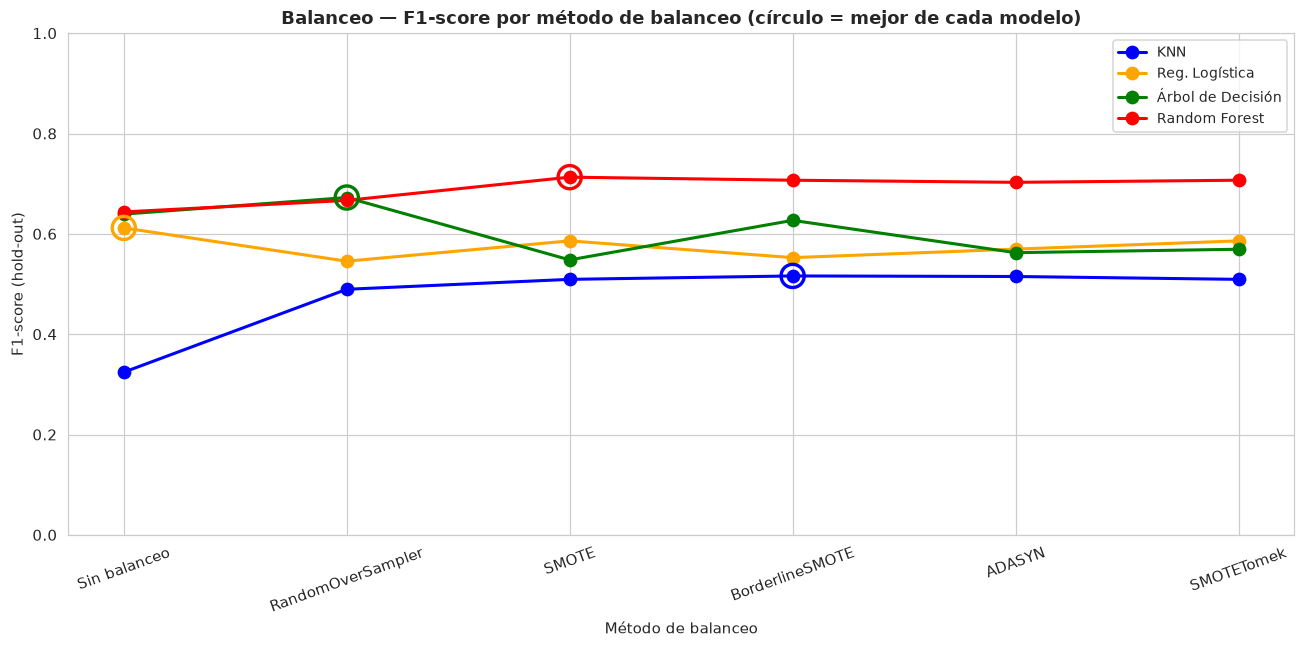

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
metodos = list(BALANCEADORES); x = np.arange(len(metodos))
for mod in MODELOS:
    ax.plot(x, f1_bal[mod].values, marker='o', lw=2, markersize=8, color=MODEL_COLORS[mod], label=mod)
# marcador del mejor metodo de cada modelo
for mod in MODELOS:
    xi = metodos.index(mejor_bal_por_modelo[mod])
    ax.scatter([xi], [f1_bal.loc[mejor_bal_por_modelo[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(metodos, rotation=20)
ax.set_xlabel('Método de balanceo'); ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Balanceo — F1-score por método de balanceo (círculo = mejor de cada modelo)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint1/balanceo_f1_comparacion.png', bbox_inches='tight'); plt.show()

## Análisis Principal de Componentes (PCA)

### Funciones auxiliares

In [17]:
def sustento_pca(Xtr_scaled):
    '''Devuelve var_acum, eigenvalues y umbrales n80/n90/n95/kaiser.'''
    pca = PCA(random_state=SEED).fit(Xtr_scaled)
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    eigen = pca.explained_variance_
    n = {u: int(np.argmax(var_acum >= u)+1) for u in (.80,.90,.95)}
    n['kaiser'] = int(np.sum(eigen > 1))
    return var_acum, eigen, n

def graficar_sustento(var_acum, eigen, n, titulo, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    comp = np.arange(1, len(var_acum)+1)
    axes[0].plot(comp, var_acum, marker='o', ms=3, color='blue', lw=1.6)
    for u, c in [(.80,'green'),(.90,'orange'),(.95,'red')]:
        axes[0].axhline(u, ls='--', color=c, alpha=.7); axes[0].axvline(n[u], ls=':', color=c, alpha=.7)
        axes[0].text(n[u]+0.3, u-0.06, f'{int(u*100)}% → {n[u]}', color=c, fontweight='bold', fontsize=9)
    axes[0].set_xlabel('Nº componentes'); axes[0].set_ylabel('Varianza explicada acumulada')
    axes[0].set_title(f'Varianza acumulada — {titulo}', fontweight='bold')
    axes[1].plot(comp, eigen, marker='o', ms=3, color='purple', lw=1.5)
    axes[1].axhline(1.0, ls='--', color='red', label='Kaiser (eigenvalue=1)')
    axes[1].axvline(n['kaiser'], ls=':', color='red', alpha=.7)
    axes[1].text(n['kaiser']+0.3, max(eigen)*0.6, f"Kaiser → {n['kaiser']}", color='red', fontweight='bold', fontsize=9)
    axes[1].set_xlabel('Nº componentes'); axes[1].set_ylabel('Eigenvalue')
    axes[1].set_title(f'Scree plot + Kaiser — {titulo}', fontweight='bold'); axes[1].legend()
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()

def barrido_pca(Xtr_b, ytr_b):
    '''F1 hold-out para n=1..46 y cada modelo. Devuelve DataFrame (index=n, cols=modelos).'''
    sc = StandardScaler().fit(Xtr_b)
    Xtr_s = sc.transform(Xtr_b); Xte_s = sc.transform(X_test)
    tab = pd.DataFrame(index=range(1,47), columns=MODELOS, dtype=float)
    for n in range(1, 47):
        pca = PCA(n_components=n, random_state=SEED).fit(Xtr_s)
        Xtr_p = pca.transform(Xtr_s); Xte_p = pca.transform(Xte_s)
        for nb_mod, base in crear_modelos().items():
            clf = base.named_steps['clf']
            clf.fit(Xtr_p, ytr_b)
            tab.loc[n, nb_mod] = f1_score(y_test, clf.predict(Xte_p))
    return tab.astype(float).round(4)

def top5_por_modelo(tab, etiqueta):
    filas = []
    for mod in MODELOS:
        top = tab[mod].sort_values(ascending=False).head(5)
        for rank,(n,f1) in enumerate(top.items(),1):
            filas.append({'Modelo':mod,'Escenario':etiqueta,'Rank':rank,'n_comp':int(n),'F1':f1})
    return pd.DataFrame(filas)

def grafico_barrido(tab, titulo, fname):
    fig, ax = plt.subplots(figsize=(13, 6))
    for mod in MODELOS:
        ax.plot(tab.index, tab[mod], marker='o', ms=3, lw=1.7, color=MODEL_COLORS[mod], label=mod)
        n_best = int(tab[mod].idxmax())
        ax.scatter([n_best],[tab[mod].max()], s=200, facecolors='none',
                   edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
    ax.set_xlabel('Nº de componentes PCA (1–46)'); ax.set_ylabel('F1-score (hold-out)')
    ax.set_title(titulo, fontweight='bold'); ax.set_xlim(0,47); ax.set_ylim(0,1); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()
print('Funciones de PCA listas.')

Funciones de PCA listas.


### PCA sin balanceo

PCA (sin balanceo) → Kaiser=13 | 80%=14 | 90%=22 | 95%=28


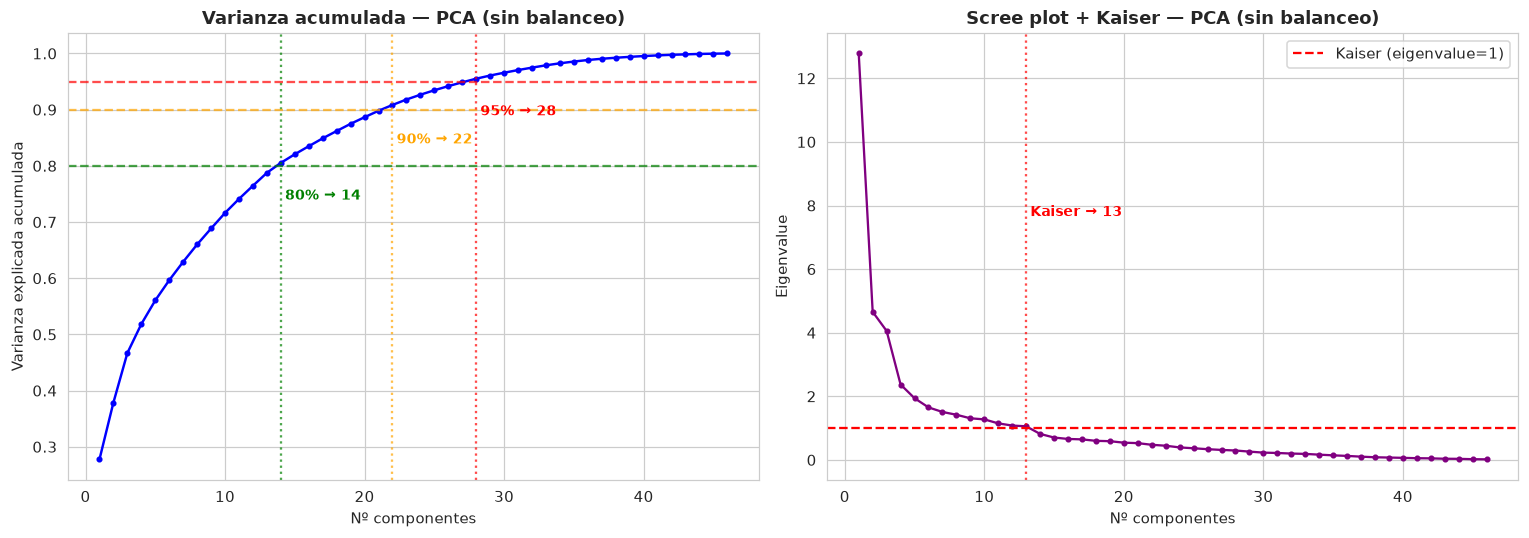

In [18]:
sc0 = StandardScaler().fit(X_train)
va0, eig0, n0 = sustento_pca(sc0.transform(X_train))
print(f"PCA (sin balanceo) → Kaiser={n0['kaiser']} | 80%={n0[.80]} | 90%={n0[.90]} | 95%={n0[.95]}")
graficar_sustento(va0, eig0, n0, 'PCA (sin balanceo)', 'outputs_sprint1/PCA_sinbalanceo.png')

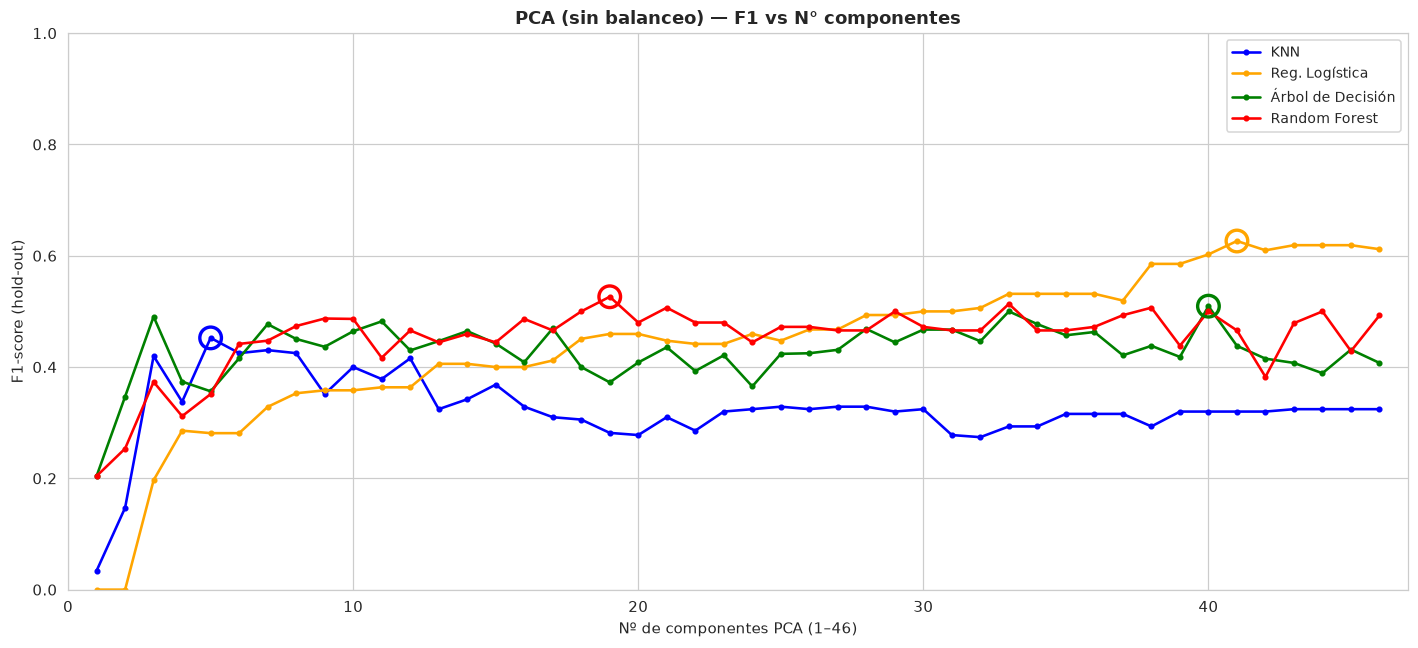

In [19]:
tab_pca_e1 = barrido_pca(X_train, y_train)
tab_pca_e1.to_csv('outputs_sprint1/PCA_sinbalanceo_f1.csv')
grafico_barrido(tab_pca_e1, 'PCA (sin balanceo) — F1 vs N° componentes',
                'outputs_sprint1/PCA_sinbalanceo_comparacion_f1.png')

In [20]:
top5_e1 = top5_por_modelo(tab_pca_e1, 'PCA sin balanceo')
top5_e1.to_csv('outputs_sprint1/PCA_sinbalanceo_top5.csv', index=False)
top5_e1.pivot(index='Rank', columns='Modelo', values='n_comp')  # n_comp del top5
print('Top-5 (n_comp | F1) por modelo - PCA (sin balanceo):')
top5_e1.assign(comp_F1=lambda d: d['n_comp'].astype(str)+'  ('+d['F1'].map('{:.3f}'.format)+')')\
       .pivot(index='Rank', columns='Modelo', values='comp_F1')

Top-5 (n_comp | F1) por modelo - PCA (sin balanceo):


Modelo,KNN,Random Forest,Reg. Logística,Árbol de Decisión
Rank,,,,
1,5 (0.452),19 (0.526),41 (0.626),40 (0.509)
2,7 (0.430),33 (0.513),44 (0.619),33 (0.500)
3,8 (0.425),21 (0.507),45 (0.619),3 (0.491)
4,6 (0.425),38 (0.507),43 (0.619),11 (0.482)
5,3 (0.420),44 (0.500),46 (0.612),7 (0.477)


### PCA con el mejor balanceo de cada modelo

Mejor balanceo por modelo: {'KNN': 'BorderlineSMOTE', 'Reg. Logística': 'Sin balanceo', 'Árbol de Decisión': 'RandomOverSampler', 'Random Forest': 'SMOTE'}
Métodos únicos a sustentar en PCA (con balanceo): ['BorderlineSMOTE', 'RandomOverSampler', 'SMOTE', 'Sin balanceo']


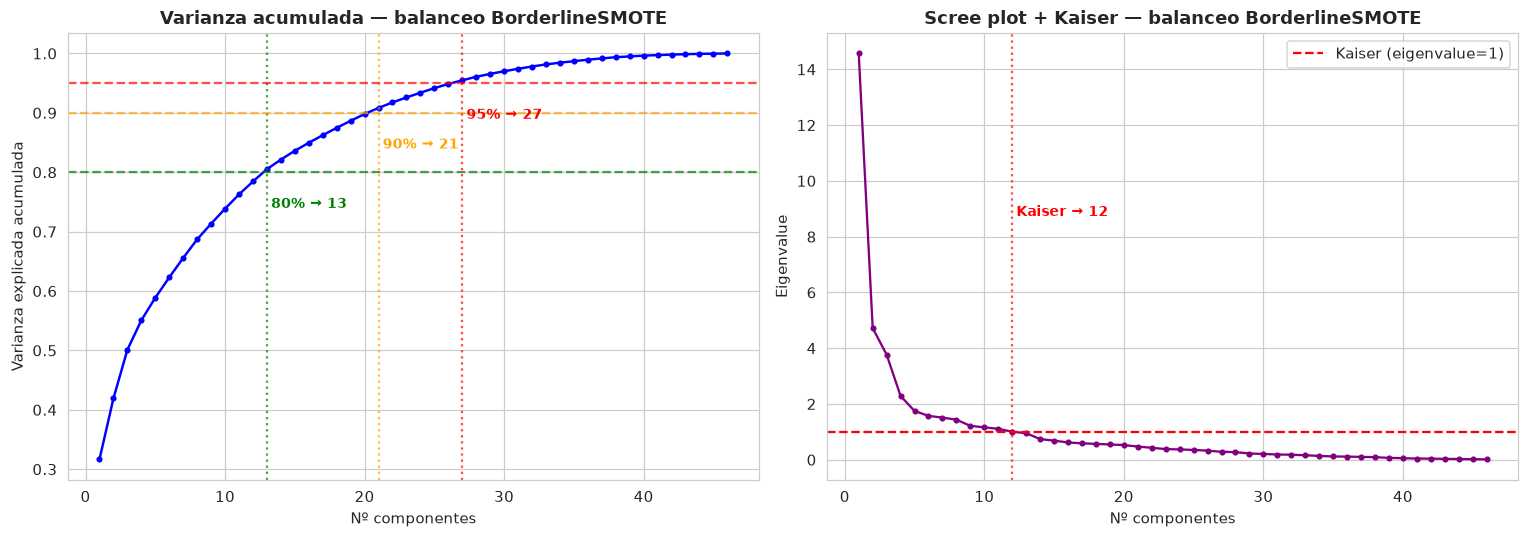

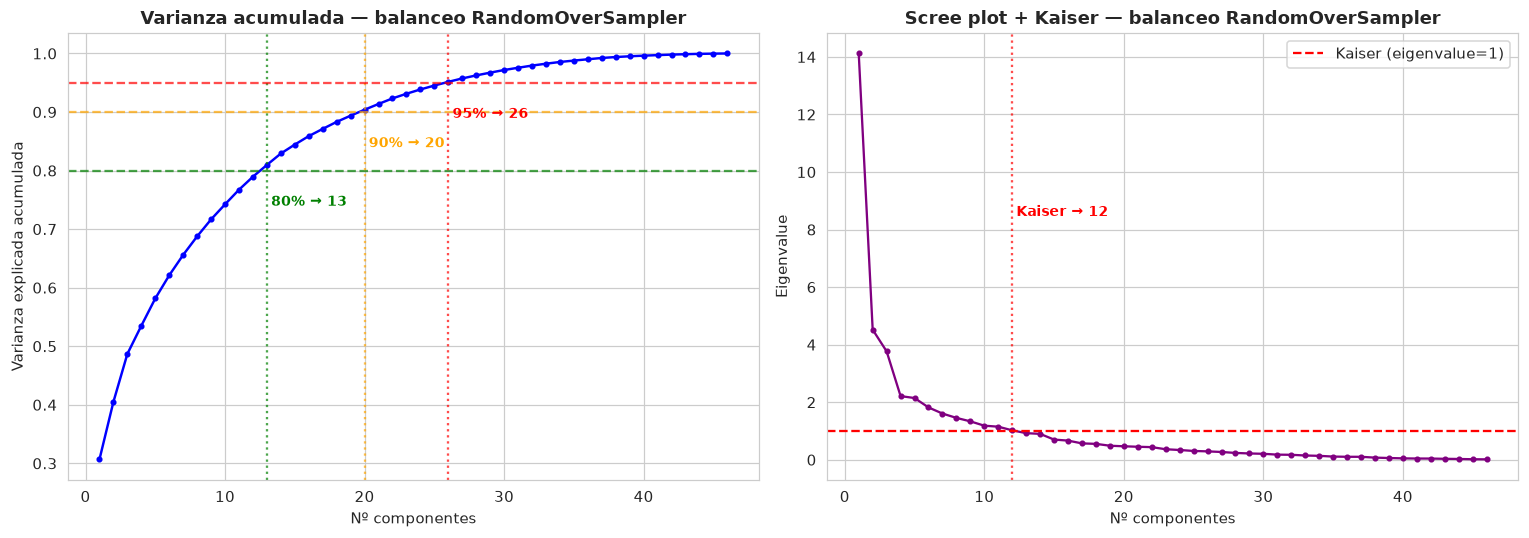

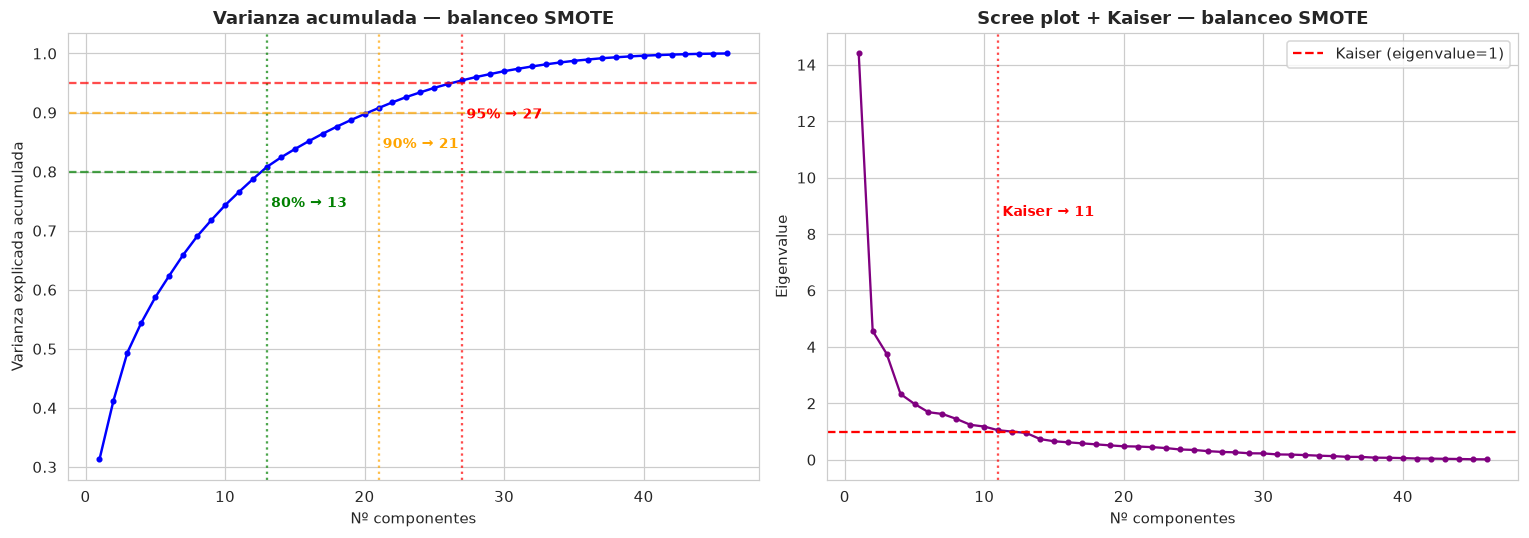

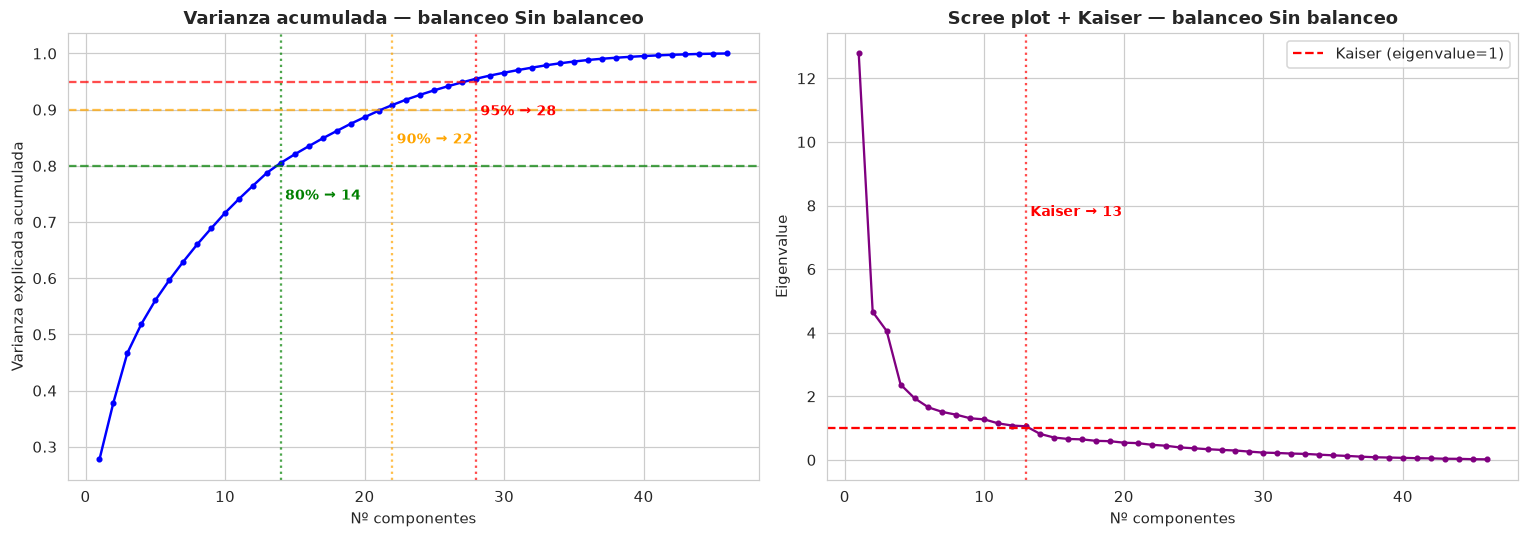

Umbrales de componentes por escenario/balanceo:


,Balanceo,Kaiser,80%,90%,95%
0,Sin balanceo,13,14,22,28
1,BorderlineSMOTE,12,13,21,27
2,RandomOverSampler,12,13,20,26
3,SMOTE,11,13,21,27
4,Sin balanceo,13,14,22,28


In [30]:
# Metodos de balanceo unicos ganadores (excluyendo 'Sin balanceo')
metodos_unicos = sorted(set(v for v in mejor_bal_por_modelo.values()))
print('Mejor balanceo por modelo:', mejor_bal_por_modelo)
print('Métodos únicos a sustentar en PCA (con balanceo):', metodos_unicos)

# Sustento + tabla resumen de umbrales por metodo de balanceo unico
filas_umbral = [{'Balanceo':'Sin balanceo','Kaiser':n0['kaiser'],'80%':n0[.80],'90%':n0[.90],'95%':n0[.95]}]
for met in metodos_unicos:
    Xb, yb = aplicar_balanceo(met)
    va, eig, nn = sustento_pca(StandardScaler().fit(Xb).transform(Xb))
    filas_umbral.append({'Balanceo':met,'Kaiser':nn['kaiser'],'80%':nn[.80],'90%':nn[.90],'95%':nn[.95]})
    graficar_sustento(va, eig, nn, f'balanceo {met}',
                      f'outputs_sprint1/PCA_conbalanceo_{met}.png')
tabla_umbrales = pd.DataFrame(filas_umbral)
tabla_umbrales.to_csv('outputs_sprint1/PCA_conbalanceo_umbrales.csv', index=False)
print('Umbrales de componentes por escenario/balanceo:')
tabla_umbrales

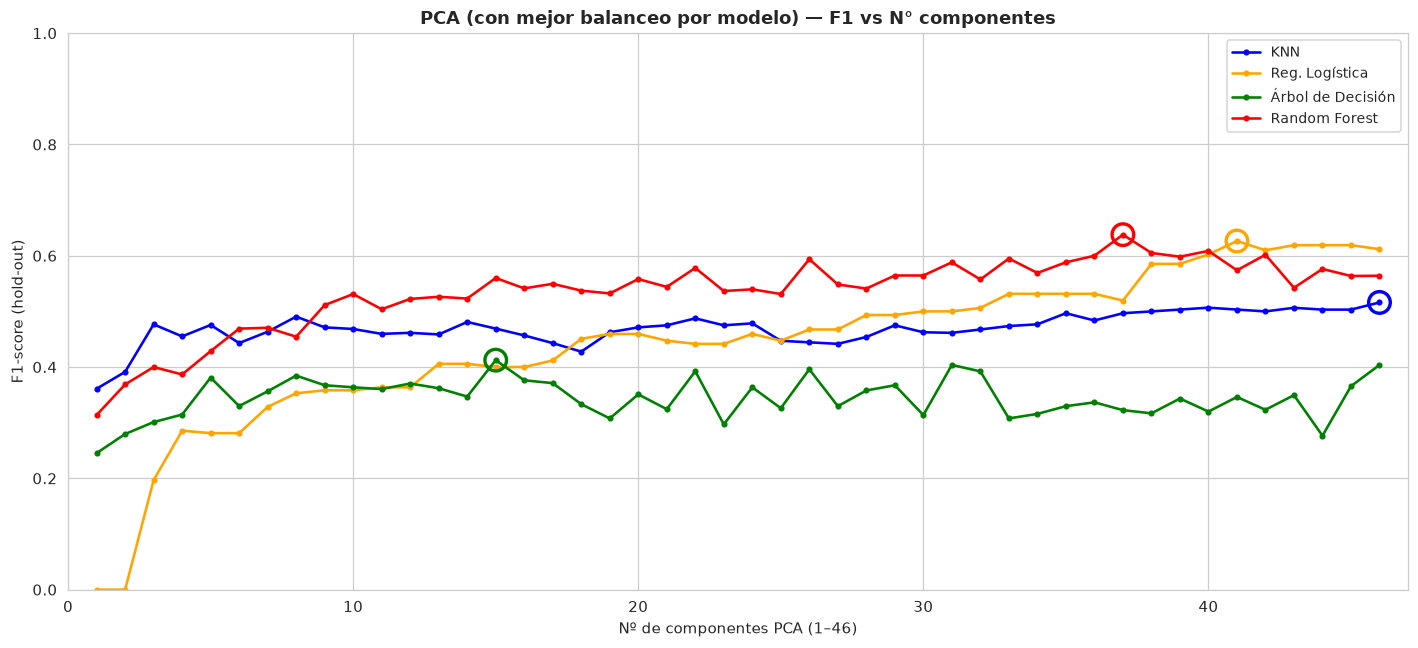

In [32]:
# Barrido PCA E2: cada modelo con SU mejor balanceo (se cachea por metodo para no recalcular)
_cache = {}
def barrido_para_metodo(met):
    if met not in _cache:
        Xb, yb = aplicar_balanceo(met)
        _cache[met] = barrido_pca(Xb, yb)
    return _cache[met]

tab_pca_e2 = pd.DataFrame(index=range(1,47), columns=MODELOS, dtype=float)
for mod in MODELOS:
    met = mejor_bal_por_modelo[mod]
    tab_pca_e2[mod] = barrido_para_metodo(met)[mod]
tab_pca_e2 = tab_pca_e2.astype(float).round(4)
tab_pca_e2.to_csv('outputs_sprint1/PCA_conbalanceo_f1.csv')
grafico_barrido(tab_pca_e2, 'PCA (con mejor balanceo por modelo) — F1 vs N° componentes',
                'outputs_sprint1/PCA_conbalanceo_comparacion_f1.png')

## Comparativa Final

In [35]:
# Reconstruye las 4 configuraciones (con todas las metricas) para cada modelo
def eval_config_solo_pca(mod, n, Xtr_b, ytr_b):
    sc = StandardScaler().fit(Xtr_b)
    Xtr_s = sc.transform(Xtr_b); Xte_s = sc.transform(X_test)
    pca = PCA(n_components=n, random_state=SEED).fit(Xtr_s)
    clf = crear_modelos()[mod].named_steps['clf']
    clf.fit(pca.transform(Xtr_s), ytr_b)
    y_pred = clf.predict(pca.transform(Xte_s))
    y_sco = clf.predict_proba(pca.transform(Xte_s))[:,1] if hasattr(clf,'predict_proba') \
            else clf.decision_function(pca.transform(Xte_s))
    return metricas(y_test, y_pred, y_sco)

filas_f1 = {}   # evolucion F1
detalle = {}    # todas las metricas por config (para tabla antes/despues)
for mod in MODELOS:
    # (1) Baseline
    m1 = {k: res_f0[mod][k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
    # (2) Solo balanceo (mejor metodo del modelo)
    met = mejor_bal_por_modelo[mod]
    Xb, yb = aplicar_balanceo(met)
    m2 = evaluar_pipeline(crear_modelos()[mod], Xb, yb, X_test, y_test)
    m2 = {k:m2[k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
    # (3) Solo PCA (mejor n del Escenario 1, sin balanceo)
    n3 = int(tab_pca_e1[mod].idxmax())
    m3 = eval_config_solo_pca(mod, n3, X_train, y_train)
    # (4) Balanceo + PCA (mejor n del Escenario 2, con el balanceo del modelo)
    n4 = int(tab_pca_e2[mod].idxmax())
    m4 = eval_config_solo_pca(mod, n4, Xb, yb)
    filas_f1[mod] = {'(1) Baseline':m1['F1'], '(2) Balanceo':m2['F1'],
                     '(3) PCA':m3['F1'], '(4) Bal+PCA':m4['F1']}
    detalle[mod] = {'Baseline':m1, 'Balanceo':m2, 'PCA':m3, 'Bal+PCA':m4,
                    '_meta':{'metodo':met,'n_pca_solo':n3,'n_pca_bal':n4}}
print('Configuraciones  evaluadas.')
print('Detalle de config por modelo (método balanceo / N° PCA solo / N° PCA con balanceo):')
for mod in MODELOS:
    mt = detalle[mod]['_meta']
    print(f"  {mod}: balanceo={mt['metodo']} | PCA solo={mt['n_pca_solo']}c | Bal+PCA={mt['n_pca_bal']}c")

Configuraciones  evaluadas.
Detalle de config por modelo (método balanceo / N° PCA solo / N° PCA con balanceo):
  KNN: balanceo=BorderlineSMOTE | PCA solo=5c | Bal+PCA=46c
  Reg. Logística: balanceo=Sin balanceo | PCA solo=41c | Bal+PCA=41c
  Árbol de Decisión: balanceo=RandomOverSampler | PCA solo=40c | Bal+PCA=15c
  Random Forest: balanceo=SMOTE | PCA solo=19c | Bal+PCA=37c


In [36]:
tab_f1_evol = pd.DataFrame(filas_f1).T.round(4)
tab_f1_evol.to_csv('outputs_sprint1/final_evolucion_f1.csv')

def resaltar_maximo_fila(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Evolución de F1 por configuración:')
tab_f1_evol.style.apply(resaltar_maximo_fila, axis=1).format('{:.4f}')

Evolución de F1 por configuración:


,(1) Baseline,(2) Balanceo,(3) PCA,(4) Bal+PCA
KNN,0.3243,0.5161,0.4524,0.5161
Reg. Logística,0.6118,0.6118,0.6265,0.6265
Árbol de Decisión,0.6393,0.6724,0.5094,0.4124
Random Forest,0.6437,0.7130,0.5263,0.6379


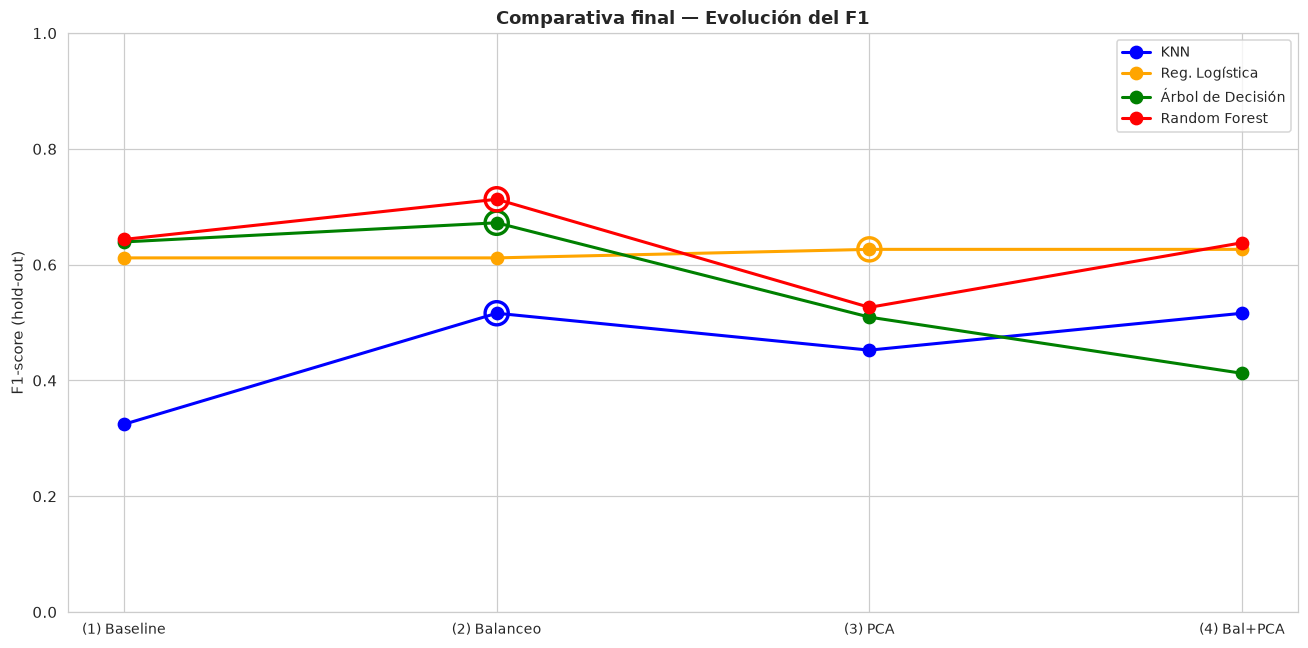

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
configs = list(next(iter(filas_f1.values())).keys())
x = np.arange(len(configs))
for mod in MODELOS:
    vals = [filas_f1[mod][c] for c in configs]
    ax.plot(x, vals, marker='o', lw=2, markersize=8, color=MODEL_COLORS[mod], label=mod)
    xb = int(np.argmax(vals))
    ax.scatter([xb],[vals[xb]], s=230, facecolors='none', edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Comparativa final — Evolución del F1', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint1/final_evolucion_f1.png', bbox_inches='tight'); plt.show()

In [39]:
METRICAS = ['F1','Accuracy','Precision','Recall','AUC-ROC']
filas = []
config_keys = {'(1) Baseline':'Baseline'}  # mapear etiqueta->key detalle
for mod in MODELOS:
    d = detalle[mod]
    # mejor config por F1 entre las 4
    opciones = {'Baseline':d['Baseline'],'Balanceo':d['Balanceo'],'PCA':d['PCA'],'Bal+PCA':d['Bal+PCA']}
    mejor_cfg = max(opciones, key=lambda k: opciones[k]['F1'])
    f1_base = d['Baseline']['F1']; f1_mejor = opciones[mejor_cfg]['F1']
    if f1_mejor > f1_base:   # solo modelos que mejoran
        for met_n in METRICAS:
            antes = d['Baseline'][met_n]; despues = opciones[mejor_cfg][met_n]
            filas.append({'Modelo':mod,'Mejor config':mejor_cfg,'Métrica':met_n,
                          'Antes (baseline)':round(antes,4),'Después':round(despues,4),
                          'Δ':round(despues-antes,4)})
if filas:
    tabla_antes_despues = pd.DataFrame(filas)
    tabla_antes_despues.to_csv('outputs_sprint1/final_antes_despues.csv', index=False)
    display(tabla_antes_despues.pivot_table(index=['Modelo','Mejor config'], columns='Métrica',
            values=['Antes (baseline)','Después','Δ']).round(4))
else:
    print('Ningún modelo mejoró respecto al baseline.')
tabla_antes_despues if filas else None

Antes (baseline)                             \
Métrica                                 AUC-ROC Accuracy      F1 Precision   
Modelo            Mejor config                                               
KNN               Balanceo               0.8390   0.8829  0.3243    0.5455   
Random Forest     Balanceo               0.9547   0.9274  0.6437    0.8000   
Reg. Logística    PCA                    0.9369   0.9227  0.6118    0.7879   
Árbol de Decisión Balanceo               0.8337   0.8970  0.6393    0.5571   

                                       Después                             \
Métrica                         Recall AUC-ROC Accuracy      F1 Precision   
Modelo            Mejor config                                              
KNN               Balanceo      0.2308  0.8751   0.8244  0.5161    0.3883   
Random Forest     Balanceo      0.5385  0.9506   0.9227  0.7130    0.6508   
Reg. Logística    PCA           0.5000  0.9344   0.9274  0.6265    0.8387   
Árbol de Decisión Balanceo      0.7500  0.8417   0.9110  0.6724    0.6094   

                                             Δ                             \
Métrica                         Recall AUC-ROC Accuracy      F1 Precision   
Modelo            Mejor config                                              
KNN               Balanceo      0.7692  0.0361  -0.0585  0.1918   -0.1571   
Random Forest     Balanceo      0.7885 -0.0041  -0.0047  0.0694   -0.1492   
Reg. Logística    PCA           0.5000 -0.0025   0.0047  0.0147    0.0508   
Árbol de Decisión Balanceo      0.7500  0.0080   0.0141  0.0331    0.0522   

                                        
Métrica                         Recall  
Modelo            Mejor config          
KNN               Balanceo      0.5385  
Random Forest     Balanceo      0.2500  
Reg. Logística    PCA           0.0000  
Árbol de Decisión Balanceo      0.0000

,Modelo,Mejor config,Métrica,Antes (baseline),Después,Δ
0,KNN,Balanceo,F1,0.3243,0.5161,0.1918
1,KNN,Balanceo,Accuracy,0.8829,0.8244,-0.0585
2,KNN,Balanceo,Precision,0.5455,0.3883,-0.1571
3,KNN,Balanceo,Recall,0.2308,0.7692,0.5385
4,KNN,Balanceo,AUC-ROC,0.8390,0.8751,0.0361
5,Reg. Logística,PCA,F1,0.6118,0.6265,0.0147
6,Reg. Logística,PCA,Accuracy,0.9227,0.9274,0.0047
7,Reg. Logística,PCA,Precision,0.7879,0.8387,0.0508
8,Reg. Logística,PCA,Recall,0.5000,0.5000,0.0000
9,Reg. Logística,PCA,AUC-ROC,0.9369,0.9344,-0.0025
